# Extra: the operand swap as a selection-policy × strength ablation (beyond-paper)

**Not part of the paper-exact reproduction** — `multilingual.ipynb` (v3, per-format
reviewed selections at the paper's strengths) remains the record. This notebook takes
the paper's cleanest intervention, the **operand swap small → hot (Fig B4)**, and asks
what it takes on Qwen3-4B by varying the two knobs the v3 run showed to be binding:
**which 6 features are steered** (selection policy) and **how hard** (strength).

Three arms, serial, everything else identical to §D of the main notebook:

| arm | small/hot selection (top-6 of the same lexicon-matched operand-token pool) | formats |
|---|---|---|
| 1 | **earliest-layer-first** = the reviewed v3 files, loaded verbatim | chat + raw |
| 2 | **highest graph influence** — the paper's one disclosed criterion, applied to the same pool (unlike v1, which took influence-top-10 per graph with no lexicon/sharing gate) | chat + raw |
| 3 | highest influence **restricted to before-middle layers** (< L18) — the closest analogue to what the paper describes ("early layers, operand token; chosen by highest graph influence") | chat only |

**Strength**: the same coupled ramp as the paper, extended tenfold — donor
`value = s × stored act` with the source at `(1 − s)× clean`, `s` swept 0 → 15 in 21
steps. The ramp passes the paper endpoint (−0.5×, +1.5×) exactly at `s = 1.5` (marked
on every panel) and reaches (−14×, +15×) at `s = 15`. ℓ is swept at the extended
endpoint per job; %-readouts (fixed measuring stick: the **reviewed** say-cold /
say-large groups + the arm's own source response) are taken at both `s = 1.5` and
`s = 15`.

Known structural facts going in (measured at selection time): the raw pool has **zero
before-middle candidates** — arm 3 is chat-only; and the chat before-middle *shared*
pool contains exactly **one** small feature (L0f133356), so arm 3's source is a
single-member supernode. Both are findings about where Qwen3 keeps these features,
not bugs.

In [1]:
%matplotlib inline
import json

import build_supernodes as B
import matplotlib.pyplot as plt
import multilingual_helper as M
import torch

from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.settings import artifacts_dir, default_device
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder

SIZE = "4b"
DEVICE = default_device()
OUT = artifacts_dir() / "paper_multilingual" / SIZE
OUT.mkdir(parents=True, exist_ok=True)
SN_INPUTS = artifacts_dir() / "supernode_inputs" / SIZE

model, tokenizer = load_qwen3(SIZE, dtype_str="bf16", device_map=DEVICE)
model.eval()
tc = load_transcoder(
    f"qwen3-{SIZE}", device=DEVICE, dtype=torch.bfloat16, lazy_decoder=False
).transcoder
N_LAYERS = len(tc)

manifest = json.loads((SN_INPUTS / "manifest.json").read_text())
GRAPH_NAMES = [f"{p}antonym_{lg}" for p in ("", "raw_") for lg in M.LANGS] + [
    "hot_en",
    "raw_hot_en",
]
dev = next(model.parameters()).device
graphs, ids, fin = {}, {}, {}
for name in GRAPH_NAMES:
    info = manifest["graphs"][name]
    graphs[name] = json.loads((SN_INPUTS / f"graph_{name}.json").read_text())
    tok_fn = M.tokenize_raw if info["raw"] else M.tokenize
    ids[name] = tok_fn(tokenizer, info["prompt"], dev)
    assert ids[name].shape[1] == info["n_tokens"], name
    fin[name] = info["final_position"]

SN = {
    fmt: M.load_supernodes(f"supernodes/multilingual_{fmt}_{SIZE}.json") for fmt in ("chat", "raw")
}

behavior = {"antonym": {}, "antonym_hot": {}}
raw_behavior = {"antonym": {}, "antonym_hot": {}}
for lg in M.LANGS:
    for key, concept in (("antonym", "small"), ("antonym_hot", "hot")):
        tid, tstr, _ = M.model_answer(model, tokenizer, M.antonym_prompt(concept, lg))
        behavior[key][lg] = {"token_id": tid, "token": tstr}
        tid, tstr, _ = M.model_answer(model, tokenizer, M.raw_antonym_prompt(concept, lg), raw=True)
        raw_behavior[key][lg] = {"token_id": tid, "token": tstr}
for lg in M.LANGS:
    assert (
        behavior["antonym"][lg]["token_id"]
        == manifest["graphs"][f"antonym_{lg}"]["answer_token_id"]
    )
    assert (
        raw_behavior["antonym"][lg]["token_id"]
        == manifest["graphs"][f"raw_antonym_{lg}"]["answer_token_id"]
    )
print(f"Qwen3-{SIZE} on {DEVICE}; behavior == manifest answers; ablation targets:")
for lg in M.LANGS:
    print(
        f"  {lg}: chat {behavior['antonym'][lg]['token']!r} -> {behavior['antonym_hot'][lg]['token']!r}, "
        f"raw {raw_behavior['antonym'][lg]['token']!r} -> {raw_behavior['antonym_hot'][lg]['token']!r}"
    )

[07/12/26 03:33:13] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[07/12/26 03:33:18] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Qwen3-4b on cuda; behavior == manifest answers; ablation targets:
  en: chat 'large' -> 'cold', raw 'large' -> 'cold'
  fr: chat 'Grand' -> 'F', raw 'grand' -> 'f'
  zh: chat '大' -> '冷', raw '大' -> '冷'


In [2]:
# The candidate pool (identical to the v3 seed pool): lexicon-matched small/hot nodes
# at the operand token of each format's graphs, small shared by >=2 of the format's
# antonym graphs; per-graph acts/positions + each member's MAX node influence recorded.
# The arms re-rank THIS pool — selection policy is the only moving part.
def operand_pool(fmt):
    p = "" if fmt == "chat" else "raw_"

    def scan(names, concept, min_graphs):
        hits, seen = {}, {}
        for name in names:
            opos = manifest["graphs"][name]["operand_position"]
            for n in B.feature_nodes(graphs[name], opos):
                mt = B.concept_match(n.get("label"), concept, "both")
                if not mt:
                    continue
                key = (n["layer"], n["feature_idx"])
                e = hits.setdefault(
                    key,
                    {
                        "layer": n["layer"],
                        "feature": n["feature_idx"],
                        "acts": {},
                        "positions": {},
                        "influence": 0.0,
                        "matched": mt,
                    },
                )
                if float(n["activation"]) > e["acts"].get(name, float("-inf")):
                    e["acts"][name] = round(float(n["activation"]), 4)
                    e["positions"][name] = n["position"]
                e["influence"] = max(e["influence"], float(n.get("influence", 0.0)))
                seen.setdefault(key, set()).add(name)
        return [e for k, e in hits.items() if len(seen[k]) >= min_graphs]

    return (
        scan([f"{p}antonym_{lg}" for lg in M.LANGS], "small", 2),
        scan([f"{p}hot_en"], "hot", 1),
    )


def top6(cands, rank, *, name):
    pool = (
        [e for e in cands if e["layer"] < N_LAYERS // 2]
        if rank == "influence_early"
        else list(cands)
    )
    if rank == "early":
        pool.sort(key=lambda e: (-e["layer"], max(e["acts"].values())), reverse=True)
    else:
        pool.sort(key=lambda e: e["influence"], reverse=True)
    return {"name": name, "role": "ablation", "members": pool[:6]}


pools = {fmt: operand_pool(fmt) for fmt in ("chat", "raw")}
for fmt in ("chat", "raw"):
    # the reviewed (arm 1) members must all come from this pool — same scan, same gates
    pool_keys = {(e["layer"], e["feature"]) for e in pools[fmt][0]}
    reviewed = {(m["layer"], m["feature"]) for m in SN[fmt]["small (multilingual)"]["members"]}
    assert reviewed <= pool_keys, f"{fmt}: reviewed small members missing from the pool"

ARMS = {
    "arm1_early": {
        fmt: (SN[fmt]["small (multilingual)"], SN[fmt]["hot (multilingual)"])
        for fmt in ("chat", "raw")
    },
    "arm2_influence": {
        fmt: (
            top6(pools[fmt][0], "influence", name="small (influence-top)"),
            top6(pools[fmt][1], "influence", name="hot (influence-top)"),
        )
        for fmt in ("chat", "raw")
    },
    "arm3_influence_early": {
        "chat": (
            top6(pools["chat"][0], "influence_early", name="small (influence, <mid)"),
            top6(pools["chat"][1], "influence_early", name="hot (influence, <mid)"),
        )
    },
}
n_raw_early = sum(1 for e in pools["raw"][0] + pools["raw"][1] if e["layer"] < N_LAYERS // 2)
print(f"raw before-middle operand candidates: {n_raw_early} -> arm 3 is chat-only\n")
sel_dump = {}
for arm, per_fmt in ARMS.items():
    print(f"== {arm}")
    sel_dump[arm] = {}
    for fmt, (small_sn, hot_sn) in per_fmt.items():
        for tag, sn in (("small", small_sn), ("hot", hot_sn)):
            rows = [
                f"L{m['layer']}f{m['feature']}(a={max(m['acts'].values()):.1f},i={m.get('influence', 0):.4f})"
                for m in sn["members"]
            ]
            print(f"  {fmt} {tag:5s} n={len(sn['members'])}: " + ", ".join(rows))
        sel_dump[arm][fmt] = {
            tag: [
                {
                    "layer": m["layer"],
                    "feature": m["feature"],
                    "acts": m["acts"],
                    "influence": m.get("influence"),
                }
                for m in sn["members"]
            ]
            for tag, sn in (("small", small_sn), ("hot", hot_sn))
        }
(OUT / "extra_operand_selections.json").write_text(
    json.dumps(sel_dump, indent=1, ensure_ascii=False)
)

raw before-middle operand candidates: 0 -> arm 3 is chat-only

== arm1_early
  chat small n=6: L22f113890(a=9.7,i=0.0204), L22f42644(a=6.0,i=0.0085), L0f133356(a=6.0,i=0.0399), L22f38866(a=5.6,i=0.0071), L21f120516(a=5.5,i=0.0063), L19f77492(a=4.2,i=0.0078)
  chat hot   n=6: L5f134029(a=4.7,i=0.0141), L4f32249(a=3.2,i=0.0081), L3f75392(a=3.1,i=0.0158), L5f18203(a=3.0,i=0.0031), L3f131394(a=2.8,i=0.0162), L5f51825(a=2.2,i=0.0027)
  raw small n=6: L28f36616(a=24.4,i=0.0130), L27f29715(a=21.6,i=0.0181), L26f58650(a=20.5,i=0.0054), L28f97177(a=19.6,i=0.0020), L26f163015(a=17.2,i=0.0038), L26f30805(a=15.5,i=0.0067)
  raw hot   n=6: L27f143324(a=39.5,i=0.0242), L24f127078(a=26.5,i=0.0868), L26f119024(a=22.4,i=0.0188), L27f58824(a=20.4,i=0.0078), L25f110576(a=17.0,i=0.0070), L24f8689(a=14.1,i=0.0313)
== arm2_influence
  chat small n=6: L0f133356(a=6.0,i=0.0399), L22f113890(a=9.7,i=0.0204), L24f24991(a=15.4,i=0.0165), L27f29715(a=23.0,i=0.0148), L28f36616(a=26.0,i=0.0135), L23f99795(a=9.9,i=0.

8908

In [3]:
# Shared runner: one arm = {fmt: (small_sn, hot_sn)}, extended coupled ladder 0->15x
# (paper endpoint at s=1.5), ell swept at s=15, readouts at s=1.5 and s=15 against the
# REVIEWED say-cold/say-large groups (fixed measuring stick) + the arm's own source.
EXT = (-14.0, 15.0)  # extends the paper operand ramp (-0.5, 1.5) tenfold, same coupling
N_STEPS = 21  # 0, 0.75, ..., 15 — s = 1.5 is grid point 2
kind = "operand"

all_results, all_readouts = {}, {}


def run_arm(arm):
    results = {}
    for fmt, (small_sn, hot_sn) in ARMS[arm].items():
        beh = behavior if fmt == "chat" else raw_behavior
        donor_graph = "hot_en" if fmt == "chat" else "raw_hot_en"
        for lg in M.LANGS:
            rec = f"antonym_{lg}" if fmt == "chat" else f"raw_antonym_{lg}"
            opos = manifest["graphs"][rec]["operand_position"]
            ivs_fn = M.swap_ivs_fn(
                small_sn, rec, opos, hot_sn, donor_graph, [opos], kind=kind, strengths=EXT
            )
            expected = beh["antonym_hot"][lg]["token_id"]
            ell, curve = M.choose_swap_end_layer(model, tc, ids[rec], ivs_fn(EXT[1]), expected)
            r = M.supernode_swap_sweep(
                model,
                tc,
                ids[rec],
                ivs_fn,
                tokenizer,
                kind=kind,
                baseline_token=beh["antonym"][lg]["token_id"],
                expected_token=expected,
                patch_end_layer=ell,
                n_steps=N_STEPS,
                strengths=EXT,
            )
            r["l_max"] = curve.end_layers[0]
            r["ell_curve"] = {
                "end_layers": curve.end_layers,
                "p_expected": [round(p, 4) for p in curve.probs],
            }
            results[f"{fmt}_{lg}"] = r
            i15 = len(r["strengths"]) - 1
            i_paper = r["strengths"].index(1.5)
            print(
                f"{arm} {fmt} {lg}: l_max={r['l_max']} ell={ell} | crossover={r['crossover']} "
                f"p_exp@1.5x={r['p_expected'][i_paper]:.3f} p_exp@15x={r['p_expected'][i15]:.3f} "
                f"top@15x={r['top_tokens'][i15][:3]}"
            )
            ro = {
                "say_cold_pct_stored": (SN[fmt]["say cold (multilingual)"], donor_graph),
                "say_large_pct_baseline": (SN[fmt]["say large (multilingual)"], None),
                "source_response_pct_baseline": (small_sn, None),
            }
            rl = M.readout_layers_above([sn for sn, _ in ro.values()], ell)
            for s in (1.5, EXT[1]):
                res = M.run_feature_intervention(
                    model,
                    tc,
                    ids[rec],
                    ivs_fn(s),
                    n_bos_tokens=M.N_BOS,
                    patch_end_layer=ell,
                    readout_layers=rl,
                )
                row = {
                    name: M.supernode_readout(
                        res, sn, rec, final_pos=fin[rec], ref_graph=rg, patch_end_layer=ell
                    )
                    for name, (sn, rg) in ro.items()
                }
                all_readouts[f"{arm}_{fmt}_{lg}@{s:g}x"] = row
                M.print_readout_row(f"   @{s:g}x [ell={ell}]", row)
    all_results[arm] = results
    return results


def arm_panel(arm, results, fname):
    fmts = sorted({k.split("_")[0] for k in results})
    fig, axes = plt.subplots(len(fmts), 3, figsize=(12.8, 3.6 * len(fmts)), squeeze=False)
    for ri, fmt in enumerate(fmts):
        beh = behavior if fmt == "chat" else raw_behavior
        token_strs = {
            lg: (beh["antonym"][lg]["token"].strip(), beh["antonym_hot"][lg]["token"].strip())
            for lg in M.LANGS
        }
        M.plot_swap_sweeps(
            {lg: results[f"{fmt}_{lg}"] for lg in M.LANGS},
            tokenizer,
            token_strs,
            title="",
            ax_row=axes[ri],
        )
        for ax in axes[ri]:
            ax.axvline(1.5, color="grey", ls=":", alpha=0.8)
            ax.text(1.5, 1.0, " paper", color="grey", fontsize=7, va="top")
        axes[ri][0].set_ylabel(f"{fmt}\nnext-token probability")
    fig.suptitle(f"{arm}: operand swap, extended ladder (constrained at the swept ell)")
    fig.tight_layout()
    fig.savefig(OUT / fname, dpi=130, bbox_inches="tight")
    plt.show()

## Arm 1 — earliest-first top-6 (the reviewed v3 selection), strength → 15×

The v3 files loaded verbatim (`small` chat L0–22 / raw L26–28; `hot` chat L3–5 / raw
L24–27). v3 measured 13% say-cold recruitment at the paper's +1.5×; the question here
is whether the same early sets flip the output at any strength up to 10× that.

arm1_early chat en: l_max=22 ell=22 | crossover=2.25 p_exp@1.5x=0.000 p_exp@15x=0.814 top@15x=[('cold', 0.814), ('Cold', 0.036), ('south', 0.022)]
readout    @1.5x [ell=22]: say_cold 13.1% (n=6), say_large 43.2% (n=6), source_response None% (n=0, 6 pinned)


readout    @15x [ell=22]: say_cold 0.7% (n=6), say_large 3.6% (n=6), source_response None% (n=0, 6 pinned)


arm1_early chat fr: l_max=22 ell=23 | crossover=4.5 p_exp@1.5x=0.000 p_exp@15x=0.269 top@15x=[('f', 0.731), ('F', 0.269), ('S', 0.0)]
readout    @1.5x [ell=23]: say_cold 30.3% (n=6), say_large 54.1% (n=5, 1 pinned), source_response None% (n=0, 6 pinned)


readout    @15x [ell=23]: say_cold 63.5% (n=6), say_large 0.0% (n=5, 1 pinned), source_response None% (n=0, 6 pinned)


arm1_early chat zh: l_max=22 ell=22 | crossover=4.5 p_exp@1.5x=0.000 p_exp@15x=0.998 top@15x=[('冷', 0.998), ('寒', 0.001), ('"', 0.001)]
readout    @1.5x [ell=22]: say_cold 4.3% (n=6), say_large 69.3% (n=6), source_response None% (n=0, 6 pinned)


...

readout    @15x [ell=35]: say_cold None% (n=0, 5 pinned), say_large None% (n=0, 6 pinned), source_response None% (n=0, 6 pinned)


arm1_early raw fr: l_max=28 ell=28 | crossover=6.0 p_exp@1.5x=0.000 p_exp@15x=0.966 top@15x=[('f', 0.966), ('cha', 0.029), ('fr', 0.001)]
readout    @1.5x [ell=28]: say_cold 3.7% (n=4, 1 pinned), say_large 78.6% (n=6), source_response None% (n=0, 6 pinned)


readout    @15x [ell=28]: say_cold 65.4% (n=4, 1 pinned), say_large 25.7% (n=6), source_response None% (n=0, 6 pinned)


arm1_early raw zh: l_max=28 ell=35 | crossover=None p_exp@1.5x=0.000 p_exp@15x=0.148 top@15x=[('大', 0.753), ('冷', 0.148), ('____', 0.02)]
readout    @1.5x [ell=35]: say_cold None% (n=0, 5 pinned), say_large None% (n=0, 6 pinned), source_response None% (n=0, 6 pinned)


readout    @15x [ell=35]: say_cold None% (n=0, 5 pinned), say_large None% (n=0, 6 pinned), source_response None% (n=0, 6 pinned)


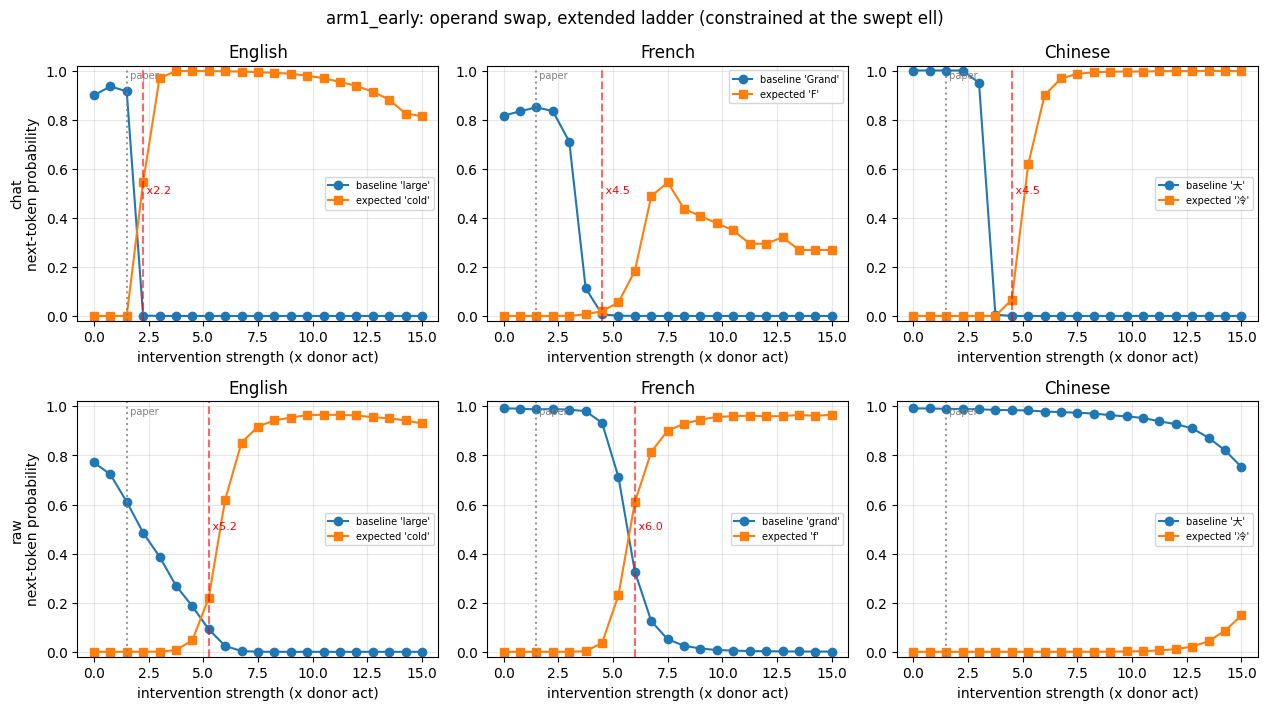

In [4]:
r1 = run_arm("arm1_early")
arm_panel("arm1_early", r1, "extra_operand_sweep_arm1.png")

## Arm 2 — influence-first top-6 (the paper's disclosed criterion), strength → 15×

Same pool, ranked by each member's max node influence (the paper: "features chosen by
highest 'graph influence'"). Expect later layers than arm 1 (influence concentrates
late on Qwen3), i.e. less protocol room but stronger members.

arm2_influence chat en: l_max=28 ell=28 | crossover=2.25 p_exp@1.5x=0.000 p_exp@15x=0.039 top@15x=[('hot', 0.538), ('Hot', 0.419), ('cold', 0.039)]
readout    @1.5x [ell=28]: say_cold 5.4% (n=4, 2 pinned), say_large 28.7% (n=4, 2 pinned), source_response None% (n=0, 6 pinned)


readout    @15x [ell=28]: say_cold 21.8% (n=4, 2 pinned), say_large 0.0% (n=4, 2 pinned), source_response None% (n=0, 6 pinned)


arm2_influence chat fr: l_max=28 ell=30 | crossover=8.25 p_exp@1.5x=0.000 p_exp@15x=0.441 top@15x=[('F', 0.441), ('f', 0.303), ('Cour', 0.053)]
readout    @1.5x [ell=30]: say_cold 0.0% (n=3, 3 pinned), say_large None% (n=0, 6 pinned), source_response None% (n=0, 6 pinned)


readout    @15x [ell=30]: say_cold 26.6% (n=3, 3 pinned), say_large None% (n=0, 6 pinned), source_response None% (n=0, 6 pinned)


arm2_influence chat zh: l_max=28 ell=35 | crossover=10.5 p_exp@1.5x=0.000 p_exp@15x=0.998 top@15x=[('冷', 0.998), ('热', 0.001), ('hot', 0.001)]
readout    @1.5x [ell=35]: say_cold None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned), source_response None% (n=0, 6 pinned)


...

readout    @15x [ell=28]: say_cold 50.9% (n=4, 1 pinned), say_large 19.4% (n=6), source_response None% (n=0, 6 pinned)


arm2_influence raw fr: l_max=28 ell=28 | crossover=6.0 p_exp@1.5x=0.000 p_exp@15x=0.979 top@15x=[('f', 0.979), ('cha', 0.016), ('fr', 0.002)]
readout    @1.5x [ell=28]: say_cold 3.9% (n=4, 1 pinned), say_large 77.9% (n=6), source_response None% (n=0, 6 pinned)


readout    @15x [ell=28]: say_cold 72.4% (n=4, 1 pinned), say_large 25.8% (n=6), source_response None% (n=0, 6 pinned)


arm2_influence raw zh: l_max=28 ell=35 | crossover=None p_exp@1.5x=0.000 p_exp@15x=0.288 top@15x=[('大', 0.61), ('冷', 0.288), ('____', 0.013)]
readout    @1.5x [ell=35]: say_cold None% (n=0, 5 pinned), say_large None% (n=0, 6 pinned), source_response None% (n=0, 6 pinned)


readout    @15x [ell=35]: say_cold None% (n=0, 5 pinned), say_large None% (n=0, 6 pinned), source_response None% (n=0, 6 pinned)


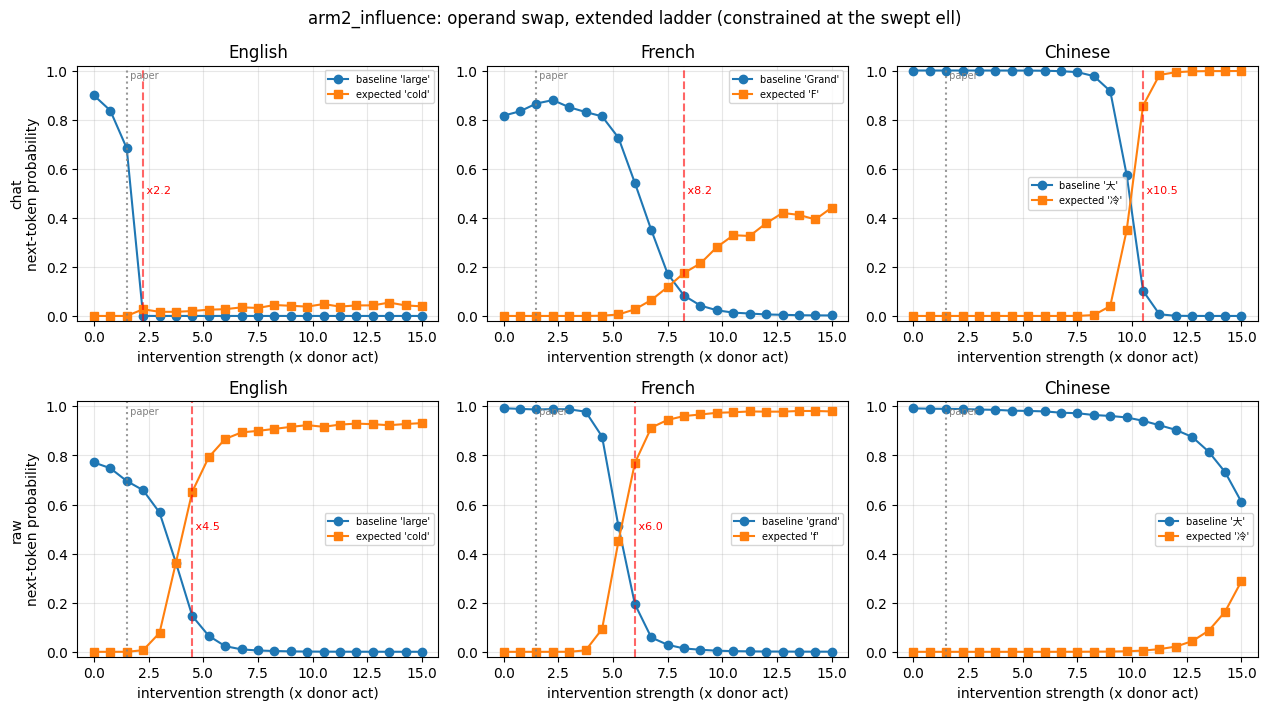

In [5]:
r2 = run_arm("arm2_influence")
arm_panel("arm2_influence", r2, "extra_operand_sweep_arm2.png")

## Arm 3 — influence-first, before-middle only (< L18), strength → 15× (chat-only)

The closest analogue to the paper's own description ("early layers, operand token,
chosen by highest graph influence"). The raw pool has zero before-middle candidates,
so this arm is chat-only — and the chat shared pool below L18 contains exactly one
small feature (L0f133356), so the source is a single-member supernode. The hot donor
pool below L18 is well-populated (L3–8).

arm3_influence_early chat en: l_max=8 ell=23 | crossover=4.5 p_exp@1.5x=0.000 p_exp@15x=0.773 top@15x=[('cold', 0.773), ('Cold', 0.221), ('hot', 0.004)]
readout    @1.5x [ell=23]: say_cold 2.7% (n=6), say_large 63.6% (n=5, 1 pinned), source_response None% (n=0, 1 pinned)


readout    @15x [ell=23]: say_cold 49.1% (n=6), say_large 5.5% (n=5, 1 pinned), source_response None% (n=0, 1 pinned)


arm3_influence_early chat fr: l_max=8 ell=22 | crossover=6.0 p_exp@1.5x=0.000 p_exp@15x=0.349 top@15x=[('f', 0.651), ('F', 0.349), ('_f', 0.0)]
readout    @1.5x [ell=22]: say_cold 27.0% (n=6), say_large 84.6% (n=6), source_response None% (n=0, 1 pinned)


readout    @15x [ell=22]: say_cold 167.1% (n=6), say_large 29.7% (n=6), source_response None% (n=0, 1 pinned)


arm3_influence_early chat zh: l_max=8 ell=8 | crossover=2.25 p_exp@1.5x=0.000 p_exp@15x=1.000 top@15x=[('冷', 1.0), ('寒', 0.0), ('凉', 0.0)]
readout    @1.5x [ell=8]: say_cold 8.2% (n=6), say_large 57.7% (n=6), source_response None% (n=0, 1 pinned)


readout    @15x [ell=8]: say_cold 69.9% (n=6), say_large 21.0% (n=6), source_response None% (n=0, 1 pinned)


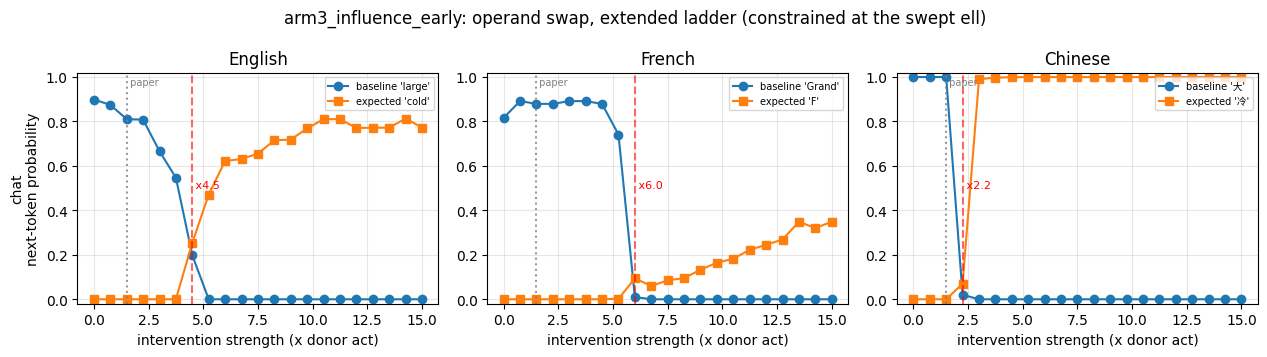

In [6]:
r3 = run_arm("arm3_influence_early")
arm_panel("arm3_influence_early", r3, "extra_operand_sweep_arm3.png")

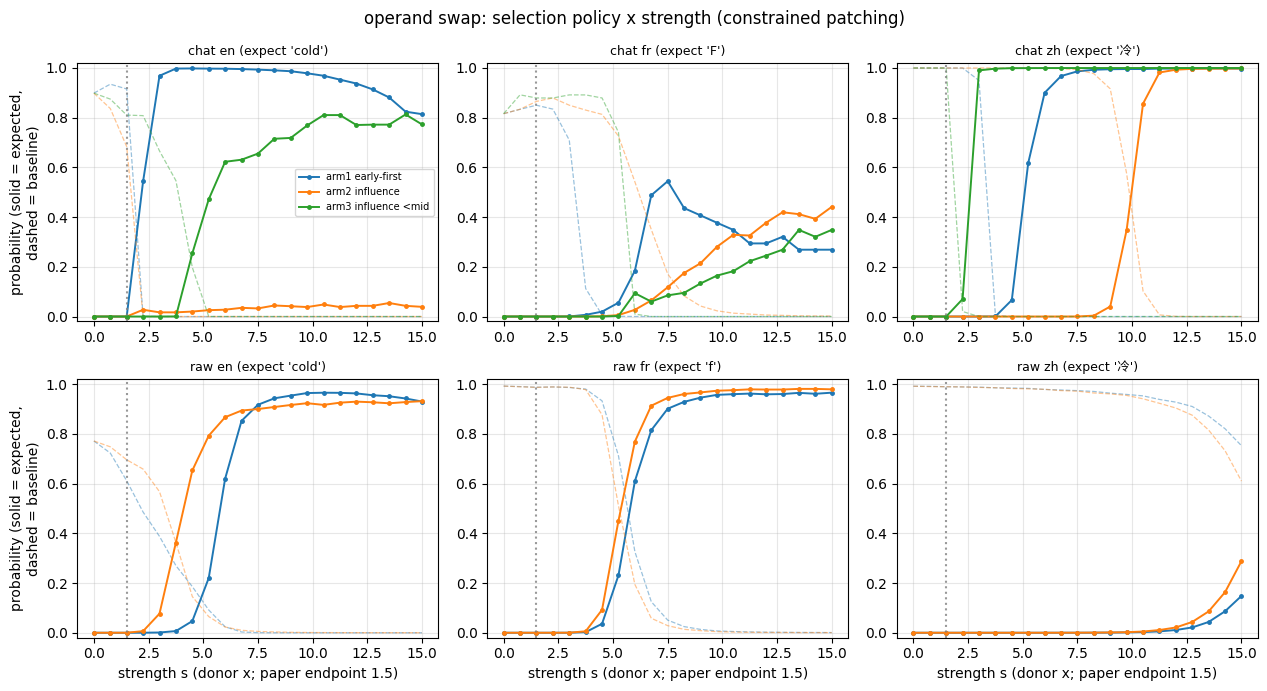

verdict lines:
  arm1_early             chat_en  ell=22 crossover=2.25 p_exp@15x=0.814 top@15x=('cold', 0.814)
  arm1_early             chat_fr  ell=23 crossover=4.5 p_exp@15x=0.269 top@15x=('f', 0.731)
  arm1_early             chat_zh  ell=22 crossover=4.5 p_exp@15x=0.998 top@15x=('冷', 0.998)
  arm1_early             raw_en   ell=35 crossover=5.25 p_exp@15x=0.930 top@15x=('cold', 0.93)
  arm1_early             raw_fr   ell=28 crossover=6.0 p_exp@15x=0.966 top@15x=('f', 0.966)
  arm1_early             raw_zh   ell=35 crossover=None p_exp@15x=0.148 top@15x=('大', 0.753)
  arm2_influence         chat_en  ell=28 crossover=2.25 p_exp@15x=0.039 top@15x=('hot', 0.538)
  arm2_influence         chat_fr  ell=30 crossover=8.25 p_exp@15x=0.441 top@15x=('F', 0.441)
  arm2_influence         chat_zh  ell=35 crossover=10.5 p_exp@15x=0.998 top@15x=('冷', 0.998)
  arm2_influence         raw_en   ell=28 crossover=4.5 p_exp@15x=0.932 top@15x=('cold', 0.932)
  arm2_influence         raw_fr   ell=28 crossove

In [7]:
# Cross-arm comparison: p(expected cold-answer) vs strength, arms overlaid per panel.
fig, axes = plt.subplots(2, 3, figsize=(12.8, 7.0), squeeze=False)
STYLE = {
    "arm1_early": ("C0", "arm1 early-first"),
    "arm2_influence": ("C1", "arm2 influence"),
    "arm3_influence_early": ("C2", "arm3 influence <mid"),
}
for ri, fmt in enumerate(("chat", "raw")):
    for ci, lg in enumerate(M.LANGS):
        ax = axes[ri][ci]
        for arm, res in all_results.items():
            r = res.get(f"{fmt}_{lg}")
            if r is None:
                continue
            c, lab = STYLE[arm]
            ax.plot(r["strengths"], r["p_expected"], "o-", ms=2.5, lw=1.4, color=c, label=lab)
            ax.plot(r["strengths"], r["p_baseline"], "--", lw=0.9, color=c, alpha=0.45)
        ax.axvline(1.5, color="grey", ls=":", alpha=0.8)
        beh = behavior if fmt == "chat" else raw_behavior
        ax.set_title(f"{fmt} {lg} (expect {beh['antonym_hot'][lg]['token'].strip()!r})", fontsize=9)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.3)
        if ri == 0 and ci == 0:
            ax.legend(fontsize=7)
        if ci == 0:
            ax.set_ylabel("probability (solid = expected,\ndashed = baseline)")
        if ri == 1:
            ax.set_xlabel("strength s (donor x; paper endpoint 1.5)")
fig.suptitle("operand swap: selection policy x strength (constrained patching)")
fig.tight_layout()
fig.savefig(OUT / "extra_operand_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

(OUT / "extra_operand_results.json").write_text(
    json.dumps(all_results, indent=1, ensure_ascii=False, default=str)
)
(OUT / "extra_operand_readouts.json").write_text(
    json.dumps(all_readouts, indent=1, ensure_ascii=False, default=str)
)
print("verdict lines:")
for arm, res in all_results.items():
    for key, r in res.items():
        i15 = len(r["strengths"]) - 1
        print(
            f"  {arm:22s} {key:8s} ell={r['patch_end_layer']:2d} crossover={r['crossover']} "
            f"p_exp@15x={r['p_expected'][i15]:.3f} top@15x={r['top_tokens'][i15][0]}"
        )

## Summary

**The operand swap lands on Qwen3-4B under the paper's constrained protocol — at
1.5–7× the paper's strength.** 14 of 15 configurations flip to the language-appropriate
cold-answer (crossovers 2.25–10.5× on the donor axis; the paper's endpoint is 1.5×).
At the paper's own strength nothing flips in any arm — v3's "room without strength"
verdict, now quantified as a ~1.5–4× strength shortfall for the early sets.

| arm | chat en / fr / zh | raw en / fr / zh |
|---|---|---|
| 1 early-first (reviewed v3) | cold @ .81 (×2.25) / f @ .73 (×4.5) / 冷 @ .998 (×4.5) | cold @ .93 (×5.25) / f @ .97 (×6) / **no flip** (大 holds @ .75) |
| 2 influence-first | **echoes `hot`** @ .54 at 15× (crossed ×2.25 then degenerated) / F @ .44 (×8.25) / 冷 @ .998 (×10.5) | cold @ .93 (×4.5) / f @ .98 (×6) / **no flip** (大 @ .61) |
| 3 influence, < mid (chat-only) | cold @ .77 (×4.5) / f @ .65 (×6) / **冷 @ 1.000 (×2.25, ℓ=8)** | — (raw pool has no before-middle candidates) |

**Findings**

1. **Strength was the missing factor, not selection or protocol.** All three policies
   flip once the ladder passes ≈2–6×; the paper's ±(−0.5, +1.5) is simply below Qwen3's
   threshold for these features. The paper's own caveat ("intervention strengths
   required are quite high relative to the feature activations") transfers with a
   larger constant.
2. **Arm 3 is the showcase** — the paper's own described recipe (influence-chosen,
   early layers), where it exists on Qwen3: chat zh flips at **2.25×** under ℓ=8 (full
   recompute room) to 冷 @ 1.000 with `say cold` recruited to 70% and `say large` down
   to 21% — the complete Fig B4 phenomenology at ~1.5× paper strength. Its source is
   the single before-middle shared small feature (L0f133356) plus early hot donors.
3. **The push–pull annotations appear at full amplitude where flips happen**:
   `say cold` 49–167% of donor level at 15× (vs 2–30% at the paper endpoint),
   `say large` collapsing to 0–30%. One dissociation: arm 1 chat en flips
   (cold @ .81) while the reviewed say-cold group stays nearly silent (0.7%) — at
   extreme strength the flip can route around the reviewed readout features.
4. **Failure modes are informative**: raw zh never flips in any arm (大 @ .61–.75 even
   at ±14/15× — the one persistent negative, consistent with its all-late selections
   and ℓ=35 direct-effect regime), and arm 2's chat en over-drive lands on the
   **echo** of the injected operand (`hot` @ .54) rather than its antonym — the same
   echo degeneration v1's propagate endpoint showed.
5. Policy ranking, if one must: early-first (arm 1) crosses earliest on chat and is
   the reviewed artifact; influence-first (arm 2) needs more strength and degenerates
   first; influence-before-middle (arm 3) is cleanest where its pool exists — but the
   pool is nearly empty on this model (one shared small feature below L18, zero raw).

**Caveats.** Beyond-paper strengths throughout (the ladder end is source −14× /
donor +15×); ℓ swept at the extended endpoint; readout groups fixed to the reviewed v3
sets; arm 2/3 selections are computed in-cell (this notebook ablates selection policy —
the reviewed files remain the reproduction of record, and `multilingual.ipynb` is
unchanged).